In [ ]:
# DBpedia embedding subset (local Parquet)

#Explores `data/dbpedia_openai3_large_10k.parquet` produced by `load_dbpedia_subset.py`.

#**Run order:** top to bottom. Install once: `pip install pandas pyarrow matplotlib numpy scikit-learn`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path to the file from load_dbpedia_subset.py (change if you used -o elsewhere)
PARQUET = Path("data/dbpedia_openai3_large_10k.parquet")
EMB_COL = "text-embedding-3-large-1536-embedding"

assert PARQUET.is_file(), f"Missing {PARQUET.resolve()} — run load_dbpedia_subset.py first."

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_parquet(PARQUET)

print("shape (rows, cols):", df.shape)
print("\ncolumns:", list(df.columns))
print("\ndtypes:\n", df.dtypes)
print("\nmemory usage (approx):", f"{df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

shape (rows, cols): (10000, 4)

columns: ['_id', 'title', 'text', 'text-embedding-3-large-1536-embedding']

dtypes:
 _id                                      object
title                                    object
text                                     object
text-embedding-3-large-1536-embedding    object
dtype: object

memory usage (approx): 7.7 MB


In [6]:
len(df)

10000

In [3]:
# First rows — quick tabular view
df.head(8)

,_id,title,text,text-embedding-3-large-1536-embedding
0,<dbpedia:Parabolic_reflector>,Parabolic reflector,A parabolic (or paraboloid or paraboloidal) re...,"[-0.02738949842751026, 0.03491175174713135, -0..."
1,<dbpedia:John_Baird_(Canadian_politician)>,John Baird (Canadian politician),"John Russell Baird, PC (born May 26, 1969) ser...","[-0.010904606431722641, -0.013850467279553413,..."
2,<dbpedia:The_80s:_A_Look_Back_at_the_Tumultuou...,The 80s: A Look Back at the Tumultuous Decade ...,The 80s: A Look Back at the Tumultuous Decade ...,"[-0.00752367964014411, -0.0036515758838504553,..."
3,<dbpedia:Shin_Sang-ok>,Shin Sang-ok,"Shin Sang-ok (October 18, 1926 – April 11, 200...","[0.041343480348587036, -0.008456620387732983, ..."
4,<dbpedia:Géza_Anda>,Géza Anda,Géza Anda (Hungarian pronunciation: [ˈɡeːzɒ ˈɒ...,"[-0.01596943661570549, 0.009690690785646439, -..."
5,<dbpedia:Marge_vs._the_Monorail>,Marge vs. the Monorail,"""Marge vs. the Monorail"" is the twelfth episod...","[-0.019495300948619843, -0.020162204280495644,..."
6,"<dbpedia:Quebec_general_election,_1989>","Quebec general election, 1989",The Quebec general election of 1989 was held o...,"[0.034889403730630875, 0.007073142100125551, -..."
7,<dbpedia:D._P._Todd_Secondary_School>,D. P. Todd Secondary School,D.P. Todd Secondary School is a public high sc...,"[0.030391348525881767, 0.004553459584712982, -..."


In [10]:
# One full example (truncate long text for display)
i = 10
row = df.iloc[i]
emb = row[EMB_COL]
print("_id:", row["_id"])
print("title:", row["title"])
print("text :\n", row["text"])
print("embedding: len =", len(emb), "| first 8 values:", np.asarray(emb, dtype=np.float32)[:10])

_id: <dbpedia:817_Squadron_RAN>
title: 817 Squadron RAN
text :
 817 Squadron was a Royal Australian Navy Fleet Air Arm squadron. It was originally formed as part of the Royal Navy's Fleet Air Arm for service during World War II and took part in combat operations in Norway, North Africa, Sicily and off the coast of France. Following the conclusion of hostilities, the squadron was disbanded in 1945. In 1950, it was re-raised as part of the Royal Australian Navy and subsequently took part in the Korean War.
embedding: len = 1536 | first 8 values: [-0.03851783  0.01961742 -0.0160467  -0.02280095 -0.001823   -0.02565465
  0.01420399  0.0182551   0.00950756  0.01560216]


In [11]:
# Average character length of `text` over all rows
text_lens = df["text"].astype(str).str.len()

print("rows:", len(text_lens))
print("mean text length (chars):", text_lens.mean())
print("median:", text_lens.median())
print("min / max:", text_lens.min(), "/", text_lens.max())

rows: 10000
mean text length (chars): 323.6832
median: 344.0
min / max: 21 / 5828



title length — min/median/max: 1 / 16 / 98

text length — min/median/max: 21 / 344 / 5828


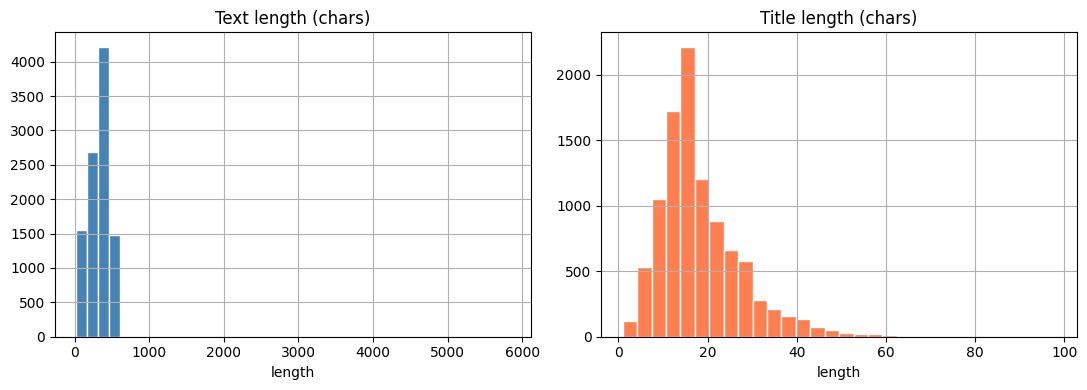

In [12]:
# Text length distribution (characters)
for col in ["title", "text"]:
    lengths = df[col].astype(str).str.len()
    print(f"\n{col} length — min/median/max: {lengths.min()} / {lengths.median():.0f} / {lengths.max()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["text"].astype(str).str.len().hist(bins=40, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].set_title("Text length (chars)")
ax[0].set_xlabel("length")

df["title"].astype(str).str.len().hist(bins=30, ax=ax[1], color="coral", edgecolor="white")
ax[1].set_title("Title length (chars)")
ax[1].set_xlabel("length")
plt.tight_layout()
plt.show()

embedding matrix shape: (10000, 1536)
L2 norm — min / median / max: 0.9999998945462492 1.0000000104117341 1.0000001258748317


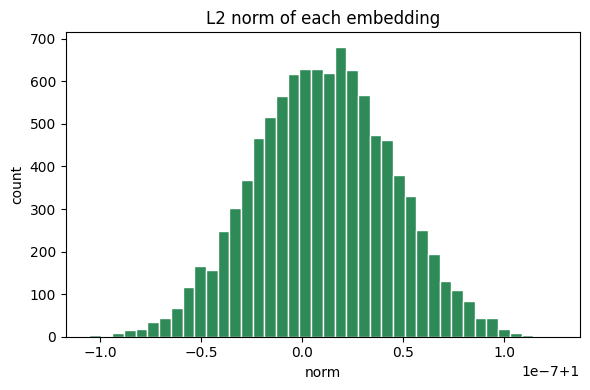

In [13]:
# Embedding norms (L2) — sanity check that vectors are non-degenerate
X = np.stack(df[EMB_COL].to_numpy())  # (n_rows, 1536)
norms = np.linalg.norm(X, axis=1)
print("embedding matrix shape:", X.shape)
print("L2 norm — min / median / max:", norms.min(), np.median(norms), norms.max())

plt.figure(figsize=(6, 4))
plt.hist(norms, bins=40, color="seagreen", edgecolor="white")
plt.title("L2 norm of each embedding")
plt.xlabel("norm")
plt.ylabel("count")
plt.tight_layout()
plt.show()

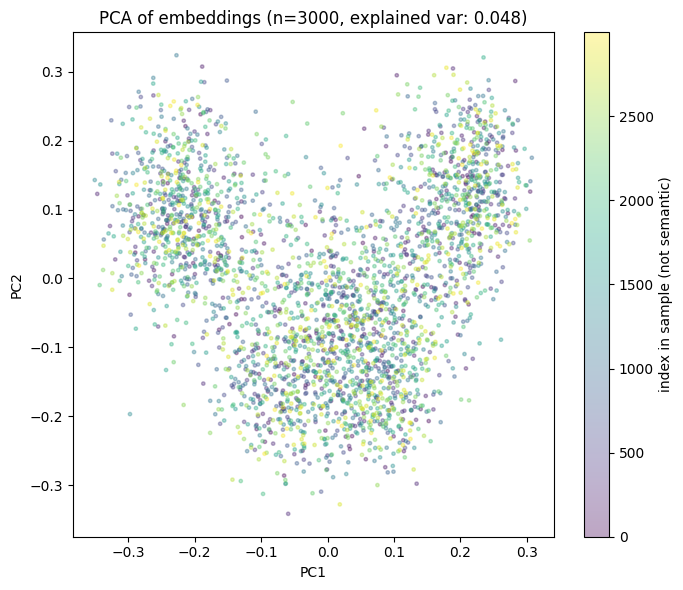

In [14]:
# 2D PCA projection (structure is approximate — for intuition only)
from sklearn.decomposition import PCA

X = np.stack(df[EMB_COL].to_numpy())
n_plot = min(3000, len(df))
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=n_plot, replace=False)
X_sub = X[idx]

pca = PCA(n_components=2, random_state=42)
XY = pca.fit_transform(X_sub)

plt.figure(figsize=(7, 6))
plt.scatter(XY[:, 0], XY[:, 1], s=6, alpha=0.35, c=np.arange(n_plot), cmap="viridis")
plt.title(f"PCA of embeddings (n={n_plot}, explained var: {pca.explained_variance_ratio_.sum():.3f})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="index in sample (not semantic)")
plt.tight_layout()
plt.show()

In [15]:
# Nearest neighbors in this slice to row 0 (cosine similarity)
# Self-contained if you skipped the PCA cell above.
X = np.stack(df[EMB_COL].to_numpy())
from numpy.linalg import norm

q = X[0]
sims = X @ q / (norm(X, axis=1) * norm(q))
# exclude self
order = np.argsort(-sims)[1:6]
print("Query title:", df.iloc[0]["title"])
print("\nTop 5 neighbors in this 10k slice (by cosine sim):")
for rank, j in enumerate(order, 1):
    print(f"  {rank}. sim={sims[j]:.4f} | {df.iloc[j]['title']}")

Query title: Parabolic reflector

Top 5 neighbors in this 10k slice (by cosine sim):
  1. sim=0.4761 | Light beam
  2. sim=0.4087 | Polarizer
  3. sim=0.4086 | Parabolic fractal distribution
  4. sim=0.3614 | Active electronically scanned array
  5. sim=0.3452 | X-ray telescope
